# 02. Feature Engineering
EDA(Day 1)에서 얻은 근거로 피처를 만들고 선별합니다. **모든 피처는 cycle ≤ 100 데이터만 사용**하며, Knee·`cycle/cycle_life` 정규화 값처럼 타깃에 의존하는 값은 쓰지 않습니다.

1. 재현성 점검: 원본 캐시 → 정제 → 피처 생성이 `data/features_cell_level.csv` 와 일치하는가
2. 후보 피처 · 선택/제외 근거
3. 배치 간 일관성(부호 뒤집힘)과 Batch 1 ↔ Batch 2 값 범위 이동

In [1]:
import sys, warnings; warnings.filterwarnings("ignore")
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))          # 저장소 루트 (src/ 임포트용)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.font_manager as fm
for f in ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]:
    if f in {x.name for x in fm.fontManager.ttflist}: plt.rcParams["font.family"] = f; break
plt.rcParams.update({"axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "figure.dpi": 110})
pd.set_option("display.width", 200); pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
ROOT = Path.cwd().parent; FIG = ROOT / "results" / "figures"

## 1. 재현성 점검 (원본 캐시가 있는 경우)

In [2]:
from src.preprocess import load_cells, clean_cells
from src.features import build_features
feat_csv = pd.read_csv(ROOT / "data" / "features_cell_level.csv")
cache = ROOT.parent / "cache" / "cells_extracted.pkl"          # Mini project/cache (저장소 밖, git 제외)
if cache.exists():
    cells = load_cells(ROOT.parent / "archive", cache)
    cells, SUMMARY, meta, attr, merges = clean_cells(cells, verbose=False)
    f = build_features(cells, SUMMARY, meta).set_index("cell_id").sort_index(); r = feat_csv.set_index("cell_id").sort_index()
    print("셀 수:", f.shape[0], "| 최대 절대 차이:", float(np.nanmax(np.abs(f[r.columns].values.astype(float) - r.values.astype(float)))))
    display(attr); display(merges[["b1", "b2", "policy_b1", "policy_b2", "b2_cycles", "published_add", "verified", "merged"]])
else:
    print("캐시가 없어 CSV 로 진행합니다 (python -m src.preprocess 로 생성 가능).")
print(feat_csv.groupby("batch").size().to_dict())

[cache] /Users/yunseojin/Desktop/Mini project/cache/cells_extracted.pkl 로드
셀 수: 120 | 최대 절대 차이: 7.105427357601002e-15


,0. 추출 직후,1. life 결측 제거,2. 이어측정 병합,4. 논문 제거 목록,5. 초기윈도우 무결성
1,46,46,46,41,41
2,47,39,39,39,39
3,46,44,44,40,40
합계,139,129,129,120,120


,b1,b2,policy_b1,policy_b2,b2_cycles,published_add,verified,merged
0,b1c0,b2c7,3.6C(80%)-3.6C,4.8C(80%)-4.8C-newstructure,806,662,False,False
1,b1c1,b2c8,3.6C(80%)-3.6C,5.2C(58%)-4C-newstructure,947,981,False,False
2,b1c2,b2c9,3.6C(80%)-3.6C,5.6C(26%)-4.5C-newstructure,819,1060,False,False
3,b1c3,b2c15,4C(80%)-4C,3.6C(9%)-5C,414,208,False,False
4,b1c4,b2c16,4C(80%)-4C,4.8C(80%)-4.8C,499,482,False,False


{1: 41, 2: 39, 3: 40}


## 2. 피처 그룹과 선택/제외 근거
| 구분 | 피처 | 근거 (Day 1 EDA) |
|---|---|---|
| 핵심 | `dq_log_var` | 수명과 상관 최상위(r≈-0.85), 세 배치 모두 같은 방향·비슷한 크기, 물리적 해석 가능 (ΔQ(V) 곡선의 변동성) |
| 보조 (ΔQ 형태) | `dq_log_abs_min`, `dq_skew`, `dq_kurt` | 분산이 못 잡는 곡선 형태 정보 |
| 보조 (초기 용량) | `QD_2`, `QD_max_minus_2` | 논문 Discharge 모델 피처 — **다만 배치 간 값 범위 이동이 큼(아래 3절)** |
| 보조 (운전/상태) | `chargetime_avg_2_6`, `Tavg_mean_2_100`, `IR_min_2_100` | ΔQ 가 설명 못 하는 부분 보완 후보 — 배치 간 부호가 뒤집혀 일반화 위험 |
| 제외 | `QD_intercept_2_100`, `t80_min`, `C_avg`, `-newstructure` 플래그, Knee 관련 | 공선성(VIF 매우 큼) / `chargetime` 과 중복 / Train 에 없는 값 / 100 사이클 시점에 알 수 없음 |

,r_B1,r_B2,r_B3,부호 일관
feature,,,,
dq_log_var,-0.847,-0.905,-0.803,O
dq_log_abs_min,-0.738,-0.864,-0.807,O
dq_skew,-0.604,-0.176,-0.331,O
dq_kurt,0.207,0.589,0.033,O
QD_2,0.088,-0.203,0.257,X
QD_max_minus_2,0.472,-0.420,0.008,X
chargetime_avg_2_6,0.731,-0.942,0.555,X
Tavg_mean_2_100,-0.461,0.393,-0.042,X
IR_min_2_100,0.359,-0.574,0.351,X


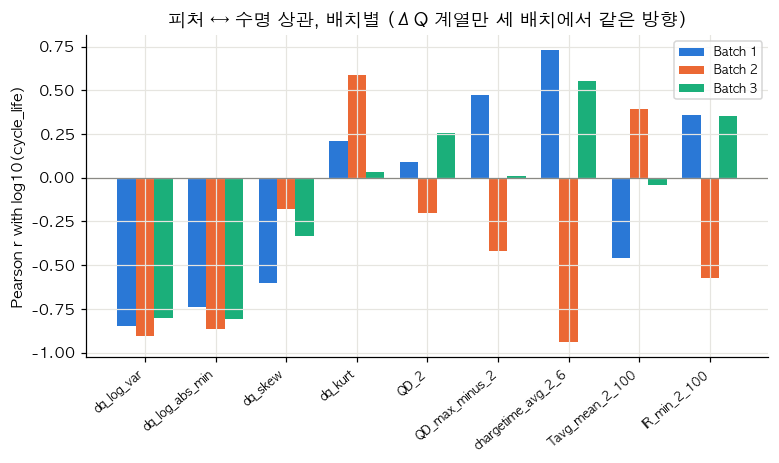

In [3]:
CAND = ["dq_log_var", "dq_log_abs_min", "dq_skew", "dq_kurt", "QD_2", "QD_max_minus_2", "chargetime_avg_2_6", "Tavg_mean_2_100", "IR_min_2_100"]
rows = []
for c in CAND:
    row = {"feature": c}
    for b in (1, 2, 3):
        g = feat_csv[feat_csv.batch == b].dropna(subset=[c]); row[f"r_B{b}"] = np.corrcoef(g[c], g.log_life)[0, 1]
    rows.append(row)
corr_b = pd.DataFrame(rows).set_index("feature")
corr_b["부호 일관"] = np.where(np.sign(corr_b.r_B1) == np.sign(corr_b.r_B2), np.where(np.sign(corr_b.r_B1) == np.sign(corr_b.r_B3), "O", "B3 다름"), "X")
display(corr_b)

fig, ax = plt.subplots(figsize=(8, 3.8)); w = .26; x = np.arange(len(CAND))
for i, (b, c) in enumerate([(1, "#2a78d6"), (2, "#eb6834"), (3, "#1baf7a")]):
    ax.bar(x + (i - 1) * w, corr_b[f"r_B{b}"], w, color=c, label=f"Batch {b}")
ax.axhline(0, color="#8a8984", lw=.8); ax.set_xticks(x, CAND, rotation=40, ha="right", fontsize=8); ax.set_ylabel("Pearson r with log10(cycle_life)")
ax.set_title("피처 ↔ 수명 상관, 배치별 (ΔQ 계열만 세 배치에서 같은 방향)"); ax.legend(fontsize=8)
fig.savefig(FIG / "fe_corr_by_batch.png", dpi=180, bbox_inches="tight"); plt.show()

## 3. Batch 1 ↔ Batch 2 값 범위 이동 (Test 라벨 미사용, 피처 분포만 비교)

In [4]:
b1, b2 = feat_csv[feat_csv.batch == 1], feat_csv[feat_csv.batch == 2]
shift = pd.DataFrame({c: {"B1 min": b1[c].min(), "B1 max": b1[c].max(), "B2 min": b2[c].min(), "B2 max": b2[c].max(),
                          "B2 중 B1 범위 밖": int(((b2[c] < b1[c].min()) | (b2[c] > b1[c].max())).sum())} for c in CAND if c not in ("IR_min_2_100",)}).T
display(shift)
print("→ QD_2 / QD_max_minus_2 는 Batch 2 셀 대부분이 Batch 1 범위 밖: 초기 용량 계열은 배치(제조 로트) 의존성이 커서 일반화 위험")

,B1 min,B1 max,B2 min,B2 max,B2 중 B1 범위 밖
dq_log_var,-5.136,-3.342,-4.443,-3.000,12.000
dq_log_abs_min,-2.050,-1.029,-1.751,-0.917,1.000
dq_skew,-0.827,0.256,-0.596,0.354,10.000
dq_kurt,-1.383,4.371,-1.373,-0.486,0.000
QD_2,1.054,1.095,1.067,1.109,22.000
QD_max_minus_2,0.002,0.007,0.000,0.014,24.000
chargetime_avg_2_6,8.965,13.409,10.036,10.224,0.000
Tavg_mean_2_100,29.942,33.895,29.882,35.668,6.000


→ QD_2 / QD_max_minus_2 는 Batch 2 셀 대부분이 Batch 1 범위 밖: 초기 용량 계열은 배치(제조 로트) 의존성이 커서 일반화 위험
